# Chapter 32 — Cycles and Remainders

> **Prerequisites:** ch031 (Modular Arithmetic), ch028 (Prime Numbers), ch023 (Integers)  
> **You will learn:**
> - How powers of integers cycle modulo n (multiplicative order)
> - Euler's totient function φ(n) and its role in bounding cycle lengths
> - Primitive roots: generators of the full multiplicative group
> - How cyclic structure is exploited in hashing, random number generation, and cryptography
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

In the previous chapter we established that `a^k mod n` is periodic. Here we study *why*, and *how long* the cycle is.

The **multiplicative order** of `a` modulo `n` is the smallest positive integer `k` such that `a^k ≡ 1 (mod n)`. We write `ord_n(a) = k`.

Every element in the group ℤ/nℤ* (nonzero residues coprime to n) has a multiplicative order. The key facts:
- The order always divides **Euler's totient** φ(n)
- When n is prime, φ(n) = n − 1
- Some elements have order exactly φ(n) — these are called **primitive roots** (or generators)

**Why this matters:**  
- Linear congruential generators (LCGs), the simplest class of pseudo-random number generators, are cycles mod n  
- The security of Diffie-Hellman key exchange rests on the hardness of computing discrete logarithms in a cyclic group  
- Hash table probing sequences rely on cycle lengths covering the full table

**Common misconception:** The cycle of `a^k mod n` returning to 1 is not the same as the sequence of remainders returning to its start. The full sequence `a, a^2, a^3, ...` cycles back to `a` after `ord_n(a)` steps — but only if `gcd(a, n) = 1`.

---

## 2. Intuition & Mental Models

**Geometric analogy — gear with n teeth:**  
Think of mod n as a gear with n teeth numbered 0 through n−1. Each multiplication by `a` advances the gear by `a` teeth. The cycle length is the number of steps before you return to your starting position.

**Computational analogy — pointer jumping in a cyclic list:**  
Imagine a circular linked list of n nodes. Starting at node 1, you jump to node `(current * a) % n` at each step. The cycle length is when you land back on 1.

**Euler's totient φ(n):**  
Think of φ(n) as the count of integers in [1, n] that are coprime to n. For prime p, every integer from 1 to p−1 qualifies, so φ(p) = p − 1. The totient is the size of the group ℤ/nℤ*, and by Lagrange's theorem (group theory), every cycle length must divide the group size.

**Recall from ch031:** We saw that a^(p-1) ≡ 1 (mod p) for prime p (Fermat's Little Theorem). This is now understood as: the order of any element divides φ(p) = p−1.

---

## 3. Visualization

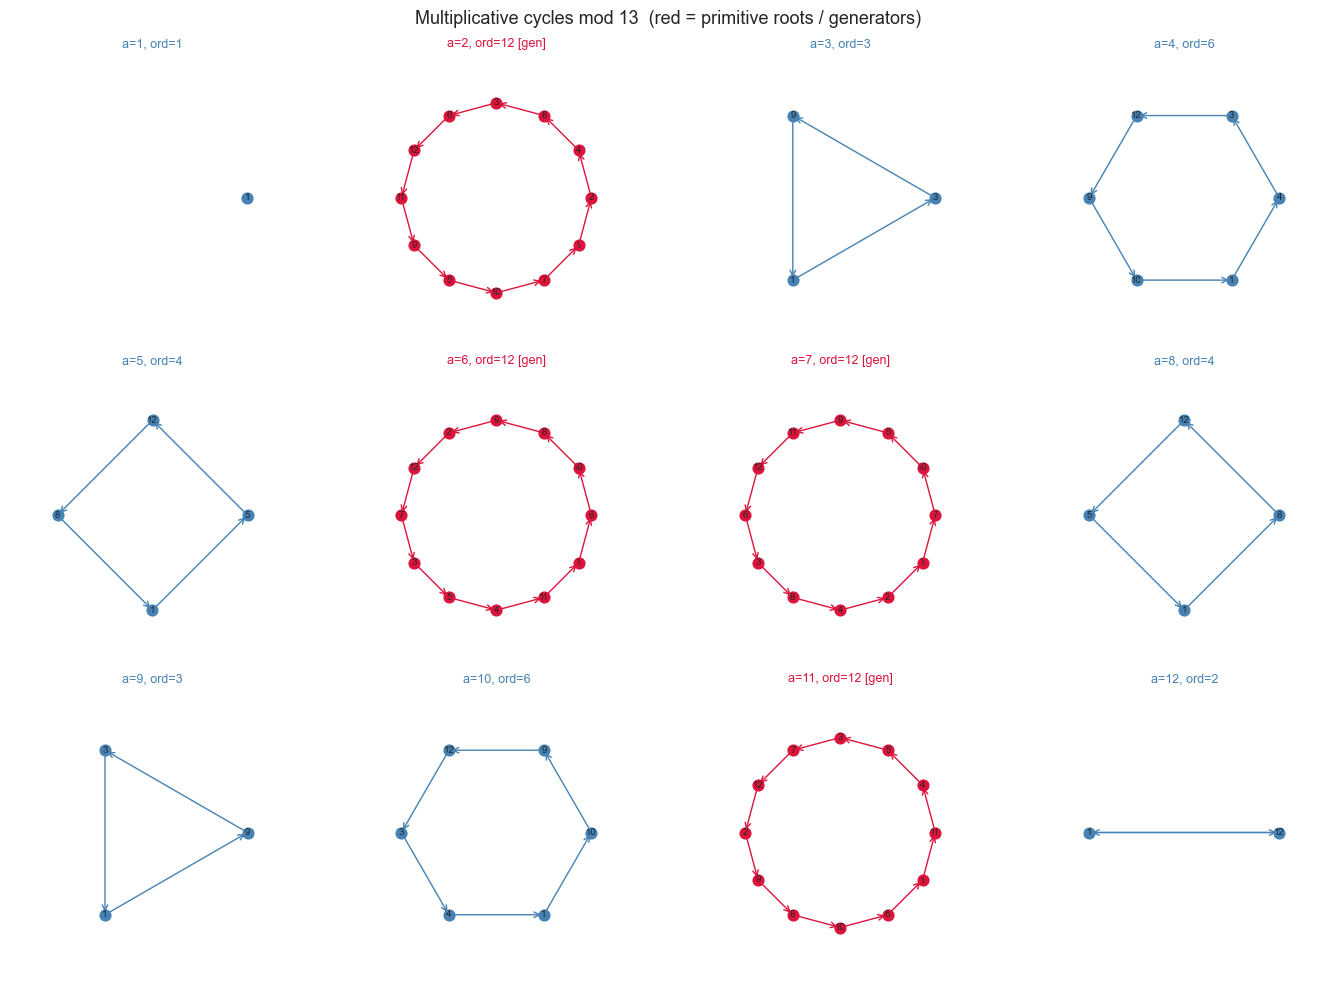

In [1]:
# --- Visualization: Multiplicative order cycles as circular graphs ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

def multiplicative_order(a, n):
    """Find smallest k > 0 such that a^k ≡ 1 (mod n). Returns None if gcd(a,n)!=1."""
    import math
    if math.gcd(a, n) != 1:
        return None
    power = a % n
    for k in range(1, n + 1):
        if power == 1:
            return k
        power = (power * a) % n
    return None

PRIME = 13   # <-- try other primes: 7, 11, 17, 19
bases = range(1, PRIME)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for idx, a in enumerate(bases):
    ax = axes[idx]
    order = multiplicative_order(a, PRIME)
    sequence = []
    val = 1
    for _ in range(order):
        val = (val * a) % PRIME
        sequence.append(val)

    # Place sequence elements on a circle
    n_pts = len(sequence)
    angles = [2 * np.pi * i / n_pts for i in range(n_pts)]
    xs = [np.cos(th) for th in angles]
    ys = [np.sin(th) for th in angles]

    color = 'crimson' if order == PRIME - 1 else 'steelblue'  # red = primitive root
    ax.scatter(xs, ys, s=60, c=color, zorder=3)
    for i in range(n_pts):
        ax.annotate(str(sequence[i]), (xs[i], ys[i]),
                    ha='center', va='center', fontsize=7)
        j = (i + 1) % n_pts
        ax.annotate('', xy=(xs[j], ys[j]), xytext=(xs[i], ys[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    label = f'a={a}, ord={order}'
    if order == PRIME - 1:
        label += ' [gen]'
    ax.set_title(label, fontsize=9, color=color)

# Hide unused subplots
for idx in range(len(bases), len(axes)):
    axes[idx].axis('off')

fig.suptitle(f'Multiplicative cycles mod {PRIME}  (red = primitive roots / generators)',
             fontsize=13)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Euler's totient function:**
```
φ(n) = n · ∏_{p | n} (1 - 1/p)
```
where the product is over distinct prime factors of n.

Examples:
- φ(p) = p − 1 for prime p
- φ(p^k) = p^k − p^(k-1)
- φ(mn) = φ(m)φ(n) when gcd(m, n) = 1 (multiplicativity)

**Euler's theorem (generalization of Fermat's Little Theorem):**
```
For gcd(a, n) = 1:   a^φ(n) ≡ 1 (mod n)
```
This means ord_n(a) always divides φ(n).

**Primitive root:**  
An integer `g` is a primitive root modulo `n` if `ord_n(g) = φ(n)`. A primitive root generates all elements of ℤ/nℤ* via its powers.

Primitive roots exist modulo: 1, 2, 4, p^k, 2p^k (for odd primes p). They do not exist modulo 8, 12, 15, etc.

**Discrete logarithm:**  
If `g` is a primitive root mod n, then for any `b` coprime to n, there exists a unique `k` in [0, φ(n)−1] such that `g^k ≡ b (mod n)`. This `k` is the **discrete logarithm** of `b` base `g` mod `n`.

Computing `g^k mod n` is fast (O(log k) multiplications). The inverse — finding `k` given `g^k mod n` — is believed to be computationally hard for large n. This asymmetry is the foundation of Diffie-Hellman.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Euler's totient, primitive roots, discrete log ---
import math
import numpy as np

def euler_totient(n):
    """
    Compute Euler's totient φ(n): count of integers in [1,n] coprime to n.

    Args:
        n: positive integer

    Returns:
        φ(n)
    """
    result = n
    p = 2
    temp = n
    while p * p <= temp:
        if temp % p == 0:
            while temp % p == 0:
                temp //= p
            result -= result // p  # result *= (1 - 1/p)
        p += 1
    if temp > 1:
        result -= result // temp
    return result


def multiplicative_order(a, n):
    """
    Compute the multiplicative order of a modulo n.
    Returns None if gcd(a, n) != 1.

    Args:
        a: integer
        n: modulus

    Returns:
        smallest k > 0 with a^k ≡ 1 (mod n), or None
    """
    if math.gcd(a, n) != 1:
        return None
    order = 1
    power = a % n
    while power != 1:
        power = (power * a) % n
        order += 1
    return order


def find_primitive_roots(n):
    """
    Find all primitive roots modulo n.

    Args:
        n: modulus

    Returns:
        list of primitive roots
    """
    phi = euler_totient(n)
    roots = []
    for a in range(2, n):
        if math.gcd(a, n) == 1 and multiplicative_order(a, n) == phi:
            roots.append(a)
    return roots


def discrete_log_brute(g, b, n):
    """
    Brute-force discrete logarithm: find k such that g^k ≡ b (mod n).
    Only feasible for small n.

    Args:
        g: generator (primitive root)
        b: target value
        n: modulus

    Returns:
        k, or None if not found
    """
    power = 1
    for k in range(euler_totient(n)):
        if power == b % n:
            return k
        power = (power * g) % n
    return None


# --- Tests ---
for n in [7, 12, 13, 15, 17]:
    phi = euler_totient(n)
    roots = find_primitive_roots(n)
    print(f"n={n:2d}: φ(n)={phi:2d}, primitive roots: {roots if roots else 'none'}")

print("\n--- Discrete log examples (mod 7, generator g=3) ---")
g, p = 3, 7
for b in range(1, p):
    k = discrete_log_brute(g, b, p)
    print(f"  {g}^{k} ≡ {b} (mod {p})   →  log_{g}({b}) mod {p} = {k}")

n= 7: φ(n)= 6, primitive roots: [3, 5]
n=12: φ(n)= 4, primitive roots: none
n=13: φ(n)=12, primitive roots: [2, 6, 7, 11]
n=15: φ(n)= 8, primitive roots: none
n=17: φ(n)=16, primitive roots: [3, 5, 6, 7, 10, 11, 12, 14]

--- Discrete log examples (mod 7, generator g=3) ---
  3^0 ≡ 1 (mod 7)   →  log_3(1) mod 7 = 0
  3^2 ≡ 2 (mod 7)   →  log_3(2) mod 7 = 2
  3^1 ≡ 3 (mod 7)   →  log_3(3) mod 7 = 1
  3^4 ≡ 4 (mod 7)   →  log_3(4) mod 7 = 4
  3^5 ≡ 5 (mod 7)   →  log_3(5) mod 7 = 5
  3^3 ≡ 6 (mod 7)   →  log_3(6) mod 7 = 3


---

## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_19800\4290400554.py:22: UserWarning: Glyph 8484 (\N{DOUBLE-STRUCK CAPITAL Z}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8484 (\N{DOUBLE-STRUCK CAPITAL Z}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


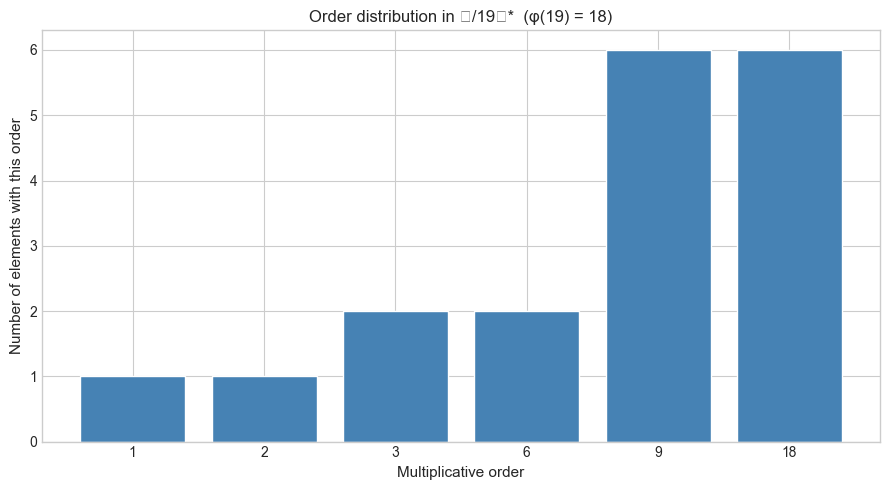

Divisors of φ(19) = 18: [1, 2, 3, 6, 9, 18]
Orders that appear: [1, 2, 3, 6, 9, 18]
φ(d) elements should have order d. Check: order 1: expected 1, got 1  |  order 2: expected 1, got 1  |  order 3: expected 2, got 2  |  order 6: expected 2, got 2  |  order 9: expected 6, got 6  |  order 18: expected 6, got 6  |  

In [3]:
# --- Experiment 1: Order distribution across elements ---
# Hypothesis: for prime p, every divisor of p-1 appears as some element's order.
# Try changing: PRIME to different values.

import matplotlib.pyplot as plt
from collections import Counter

PRIME = 19  # <-- modify: try 7, 11, 13, 17, 23

orders = [multiplicative_order(a, PRIME) for a in range(1, PRIME)]
order_counts = Counter(orders)

divisors_of_phi = [d for d in range(1, PRIME) if (PRIME - 1) % d == 0]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([str(o) for o in sorted(order_counts)],
              [order_counts[o] for o in sorted(order_counts)],
              color='steelblue', edgecolor='white')
ax.set_xlabel('Multiplicative order', fontsize=11)
ax.set_ylabel('Number of elements with this order', fontsize=11)
ax.set_title(f'Order distribution in ℤ/{PRIME}ℤ*  (φ({PRIME}) = {PRIME-1})', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Divisors of φ({PRIME}) = {PRIME-1}: {divisors_of_phi}")
print(f"Orders that appear: {sorted(order_counts.keys())}")
print(f"φ(d) elements should have order d. Check: ", end="")
for d in divisors_of_phi:
    phi_d = euler_totient(d)
    print(f"order {d}: expected {phi_d}, got {order_counts.get(d, 0)}", end='  |  ')

In [4]:
# --- Experiment 2: Linear Congruential Generator cycle length ---
# Hypothesis: a LCG x_(n+1) = (a*x_n + c) mod m achieves full period m
#             iff Hull-Dobell conditions are met.
# Try changing: a, c, m to see full vs partial cycles.

def lcg_cycle(a, c, m, seed=1):
    """Generate LCG sequence until it repeats. Returns cycle length."""
    seen = {}
    x = seed % m
    for i in range(m + 1):
        if x in seen:
            return i - seen[x], i  # (cycle_length, steps_to_enter_cycle)
        seen[x] = i
        x = (a * x + c) % m
    return m, 0

# Hull-Dobell conditions for full period:
#   1. gcd(c, m) = 1
#   2. a ≡ 1 (mod p) for every prime p dividing m
#   3. if 4 | m, then a ≡ 1 (mod 4)

M = 16   # <-- modify
test_cases = [
    (5, 3, M),   # full period
    (3, 0, M),   # no addend — partial
    (2, 1, M),   # a not ≡ 1 mod 2? let's check
    (5, 0, M),   # c=0 breaks Hull-Dobell condition 1
]

print(f"LCG cycle analysis (m={M}):")
print(f"{'a':>3}  {'c':>3}  {'cycle len':>10}  {'full period?':>14}")
print("-" * 38)
for a, c, m in test_cases:
    clen, _ = lcg_cycle(a, c, m)
    print(f"{a:>3}  {c:>3}  {clen:>10}  {'YES' if clen == m else 'NO':>14}")

LCG cycle analysis (m=16):
  a    c   cycle len    full period?
--------------------------------------
  5    3          16             YES
  3    0           4              NO
  2    1           1              NO
  5    0           4              NO


---

## 7. Exercises

**Easy 1.** Compute φ(36) by hand using the formula φ(p^a · q^b) = φ(p^a)·φ(q^b). Then verify with your `euler_totient` function.  
*(Expected: 12)*

**Easy 2.** List all primitive roots modulo 11. How many are there? How does this count relate to φ(φ(11))?  
*(Hint: the number of primitive roots mod p is always φ(p−1))*

**Medium 1.** Implement a `baby_step_giant_step` discrete logarithm algorithm — this runs in O(√p) rather than O(p). Verify it matches `discrete_log_brute` for small primes. *(Hint: split k = i·m + j where m = ⌈√p⌉, precompute giant steps)*

**Medium 2.** Implement a minimal Diffie-Hellman key exchange simulation: two parties (Alice and Bob) agree on a public prime p and generator g, each pick a private exponent, compute their public keys, then derive the shared secret. Verify both parties get the same secret.

**Hard.** Prove (computationally) Euler's theorem for n = 35: for every a in [1, 35] with gcd(a, 35) = 1, verify a^φ(35) ≡ 1 (mod 35). Then investigate: what is the minimum k such that a^k ≡ 1 (mod 35) for ALL coprime a? This minimum is the **Carmichael function** λ(n). Compute λ(35) and compare to φ(35).

---

## 8. Mini Project — LCG Random Number Generator Analysis

**Problem:** Linear Congruential Generators were the dominant pseudorandom number generators from the 1950s through the 1990s. They are fast but have known weaknesses. Your task: implement an LCG with good parameters, analyze its statistical properties, and demonstrate its most famous failure mode — visible lattice structure in 2D.

**Dataset:** LCG output sequence, generated programmatically.

In [ ]:
# --- Mini Project: LCG Random Number Generator Analysis ---
# Problem: Build an LCG, verify its period, test uniformity, reveal lattice structure.
# Task: complete TODOs and interpret the plots.

import numpy as np
import matplotlib.pyplot as plt

class LCG:
    """
    Linear Congruential Generator: x_{n+1} = (a * x_n + c) mod m
    """
    def __init__(self, a, c, m, seed=42):
        self.a = a
        self.c = c
        self.m = m
        self.state = seed % m

    def next(self):
        """Advance and return next value in [0, m-1]."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def generate(self, n):
        """Generate n values, normalized to [0, 1)."""
        return np.array([self.next() / self.m for _ in range(n)])


# Parameters from Numerical Recipes (historically widely used)
NR_LCG   = LCG(a=1664525,  c=1013904223, m=2**32, seed=12345)
# Intentionally bad LCG for comparison
BAD_LCG  = LCG(a=65539,    c=0,          m=2**31, seed=12345)  # RANDU

N = 100_000
good_samples = NR_LCG.generate(N)
bad_samples  = BAD_LCG.generate(N)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Uniformity histogram — good LCG
axes[0, 0].hist(good_samples, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Good LCG: Distribution', fontsize=12)
axes[0, 0].set_xlabel('Value (normalized)', fontsize=10)
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].axhline(N / 50, color='red', linestyle='--', label='Expected uniform')
axes[0, 0].legend()

# Uniformity histogram — bad LCG
axes[0, 1].hist(bad_samples, bins=50, color='salmon', edgecolor='white')
axes[0, 1].set_title('RANDU LCG: Distribution', fontsize=12)
axes[0, 1].set_xlabel('Value (normalized)', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)

# 2D scatter — good LCG: no visible structure
N_PLOT = 5000
axes[1, 0].scatter(good_samples[:N_PLOT], good_samples[1:N_PLOT+1],
                   s=1, alpha=0.3, color='steelblue')
axes[1, 0].set_title('Good LCG: Consecutive pairs (x_n, x_{n+1})', fontsize=12)
axes[1, 0].set_xlabel('x_n', fontsize=10)
axes[1, 0].set_ylabel('x_{n+1}', fontsize=10)

# 2D scatter — RANDU: visible lattice structure!
axes[1, 1].scatter(bad_samples[:N_PLOT], bad_samples[1:N_PLOT+1],
                   s=1, alpha=0.3, color='salmon')
axes[1, 1].set_title('RANDU: Consecutive pairs — lattice structure!', fontsize=12)
axes[1, 1].set_xlabel('x_n', fontsize=10)
axes[1, 1].set_ylabel('x_{n+1}', fontsize=10)

plt.tight_layout()
plt.show()

print("The RANDU LCG (a=65539, m=2^31) has all output triples (x_n, x_{n+1}, x_{n+2})")
print("lying on just 15 parallel planes in 3D — catastrophic for Monte Carlo methods.")

---

## 9. Chapter Summary & Connections

**What we covered:**
- The multiplicative order of `a` mod `n` is the cycle length of `a^k mod n`
- Euler's totient φ(n) counts elements coprime to n; every order divides φ(n)
- Primitive roots are generators of ℤ/nℤ* — they exist only for specific n
- The discrete logarithm is easy to compute forward, hard to invert — the basis of Diffie-Hellman
- LCGs are cycles mod m; their statistical quality depends on cycle structure and lattice properties

**Backward connection:**  
This chapter builds directly on the modular inverse and Fermat's Little Theorem *(ch031 — Modular Arithmetic)*. Euler's theorem is the generalization of FLT to composite moduli.

**Forward connections:**
- The full application of these ideas appears in **ch033 — Applications of Modulo in Programming**, which builds RSA encryption step by step
- Cyclic group structure reappears in **ch181 — Eigenvalue Computation**, where the characteristic polynomial roots can be interpreted cyclically over finite fields
- Primitive roots and discrete logarithms are central to elliptic-curve cryptography, a natural extension explored after **Part VI (Linear Algebra)**

**Going deeper:** Study *abstract algebra* — ℤ/nℤ* is a specific instance of a finite abelian group. The structure theorem for finite abelian groups explains when primitive roots exist and unifies the totient, Carmichael function, and CRT into one framework.